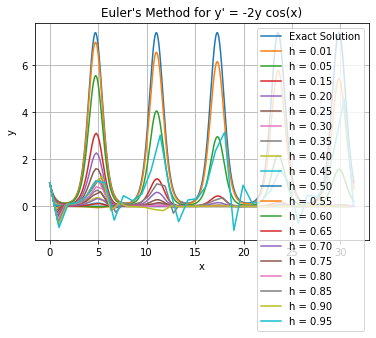

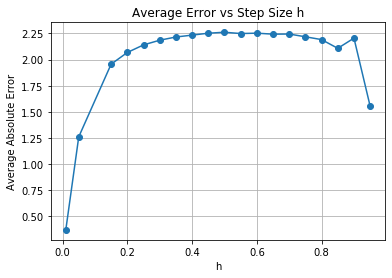

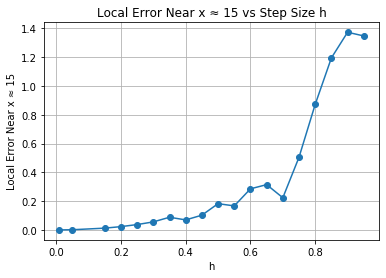

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Interval
x_start = 0
x_end = 10 * np.pi
y0 = 1

# Step sizes
h_values = [0.01, 0.05] + list(np.arange(0.15, 1.00, 0.05))

# Function
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution
def exact_solution(x):
    return np.exp(-2 * np.sin(x))

# Euler method
def euler_method(h):
    num_steps = int((x_end - x_start) / h)
    x_values = x_start + (h * np.arange(num_steps + 1))
    y_values = np.zeros(num_steps + 1)
    y_values[0] = y0

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + (h * f(x_values[i], y_values[i]))

    return x_values, y_values

# Storage
avg_error_values = []
local_error_near_15_values = []

# Plot 1: Euler solutions vs exact
plt.figure()

x_exact_plot = np.linspace(x_start, x_end, 5000)
plt.plot(x_exact_plot, exact_solution(x_exact_plot), label='Exact Solution')

for h in h_values:
    x_values, y_values = euler_method(h)

    # Average error
    y_exact = exact_solution(x_values)
    avg_error = np.mean(np.abs(y_values - y_exact))
    avg_error_values.append(avg_error)

    # Find closest to x = 15
    idx = np.argmin(np.abs(x_values - 15))

    # Local error near x = 15
    if idx < len(x_values) - 1:
        x_n = x_values[idx]
        x_np1 = x_values[idx+1]
    else:
        x_n = x_values[idx-1]
        x_np1 = x_values[idx]

    y_exact_n = exact_solution(x_n)
    y_exact_np1 = exact_solution(x_np1)

    local_error = abs(y_exact_np1 - (y_exact_n + (h * f(x_n, y_exact_n))))
    local_error_near_15_values.append(local_error)

    plt.plot(x_values, y_values, label=f"h = {h:.2f}")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for y' = -2y cos(x)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Average error vs h
plt.figure()

plt.plot(h_values, avg_error_values, marker='o')

plt.xlabel('h')
plt.ylabel('Average Absolute Error')
plt.title('Average Error vs Step Size h')
plt.grid(True)
plt.show()

# Plot 3: Local error near x = 15 vs h
plt.figure()

plt.plot(h_values, local_error_near_15_values, marker='o')

plt.xlabel('h')
plt.ylabel('Local Error Near x ≈ 15')
plt.title('Local Error Near x ≈ 15 vs Step Size h')
plt.grid(True)
plt.show()

# Explanation

I used Euler's method to approximate the solution to dy/dx = -2ycos(x), y(0) = 1 on interval [0,10pi].
The exact solution is y(x) = e^(-2sin(x))

The first plot compares the Euler approximation with exact solution. Smaller step sizes show a better approximation that looks more like the exact solution. Larger step sizes are farther from the exact solution because of accumulated deviations.

The second plot shows the average error vs. the step size. As h increases, the error increases.

The third plot shows the local error near x = 15. The local error increases as h increases, showing that each step becomes less accurate as step sizes increase.

# Addendum

dy/dx = -2ycos(x)

dy/dx = lambda*y,  lambda(x) = -2cos(x)

Stability condition: |1 - 2hcos(xn)| </= 1